# One. Step. Closer.

Here, I will further hammer in my newfound TensorFlow knowledge by translating the code found in `linear_regression_lab.ipynb` into a TensorFlow application.

After this, I will be one step closer to my own personal application of a multiple linear regression model (sounds fancy).

# Get the Boston Data

Let's first get the Boston data from the module.

In [338]:
from ISLP import load_data
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

boston = load_data("Boston")
pd.DataFrame(boston)
print(type(boston))
boston.head(10)

<class 'pandas.core.frame.DataFrame'>


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


# Inspect the data

Preview the data.

In [339]:
boston.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


No categorical data as far as I can tell. Unfortunately, the columns names are pretty useless for interpretation, but the textbook describes the relevant ones at least.

In [340]:
print(f"Data types:\n{boston.dtypes}\n")
print(f"NA values:\n{boston.isna().sum()}")

Data types:
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
lstat      float64
medv       float64
dtype: object

NA values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
lstat      0
medv       0
dtype: int64


No missing values, no problem. Let's do one more summary then convert all this to `float32` to help out TensorFlow a bit.

In [341]:
boston.describe().T

,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [342]:
boston = boston.astype("float32")
boston.dtypes

crim       float32
zn         float32
indus      float32
chas       float32
nox        float32
rm         float32
age        float32
dis        float32
rad        float32
tax        float32
ptratio    float32
lstat      float32
medv       float32
dtype: object

# Simple Linear Regression

Same as the coding lab, let's conduct a simple linear regression with `medv` as the feature and `lstat` as the label. Normally we'd inspect the data a bit more and show some graphs, but we've already done this with this data.

As a reminder:
* `medv` is median house value.
* `lstat` is the percent of households with low socioeconomic status.

First, we need to split the data up into tain and test datasets:

In [343]:
train_dataset = boston.sample(frac=0.8, random_state=0)
test_dataset = boston.drop(train_dataset.index)

Maybe it'd be better to use a `random_state` other than 0, but we'll worry about that later.

As expected, theres too many columns to digest these graphs. We'll stumble across better data inspection methodologies later. For now, we're just getting shit done.

However, at a quick first glance, you can see several of the variables are correlated in a notable manner. Maybe we'll test that out a bit later.

Actually... maybe a correlation matrix would be useful here.

In [344]:
boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355502,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


This would be a bit much to digest... Let's try and sort the correlations by the label from highest to lowest.

In [345]:
target_corrs = boston.corr()["medv"].sort_values(ascending=False)
target_corrs

medv       1.000000
rm         0.695360
zn         0.360445
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

A noteworthy application for future use. We can play around with this later. Let's get back to the main objective: translating the code to TensorFlow.

# Split Data into Train and Test

In [346]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop("medv")
test_labels = test_features.pop("medv")

# Linear Regression with One Variable

We're going to predict `medv` using `lstat`.

Before we can do anything, we need to normalize the relevant data.

## Create the Normalizer

In [350]:
normalizer = tf.keras.layers.Normalization(axis=1, name="normalizer")
normalizer.adapt(np.array(train_features))

lstat = np.array(train_features["lstat"])
lstat_normalizer = keras.layers.Normalization(input_shape=[1,], axis=None, name="lstat_normalization")
lstat_normalizer.adapt(lstat)

/Users/christiancamp/Desktop/Learning Machine Learning/An Introduction to Statistical Learning/ml-learning-linear-regression/lin-reg-env/lib/python3.13/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lin_reg_1_model = keras.Sequential([
    keras.Input(shape=[1,]),
    lstat_normalizer,
    layers.Dense(units=1, name="layer1")
], name="lin_reg_1_model")

lin_reg_1_model.summary()

Model: "lin_reg_1_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstat_normalization             │ (None, 1)              │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

## Compile and fit the model

In [358]:
lin_reg_1_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_absolute_error"
)

history = lin_reg_1_model.fit(
    train_features["lstat"],
    train_labels,
    epochs=100,
    verbose=0,
    validation_split = 0.2
)

## Visualize the model's progress

In [359]:
hist = pd.DataFrame(history.history)
hist["epoch"] = history.epoch
hist.tail()

,loss,val_loss,epoch
95,4.157665,4.798492,95
96,4.167397,4.822085,96
97,4.169742,4.841244,97
98,4.173791,4.868022,98
99,4.172214,4.852953,99


Terrible results. But that's to be expected.

## Plot the model's loss

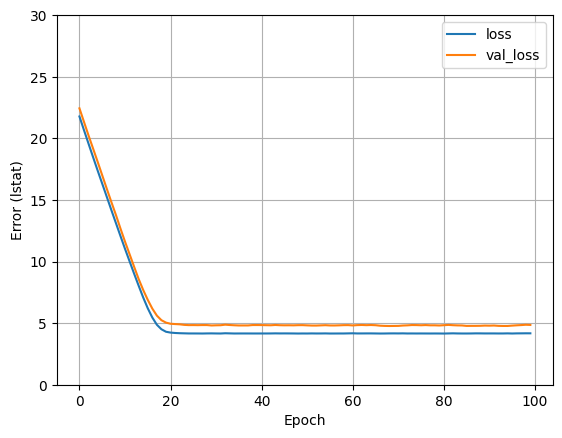

In [365]:
def plot_loss(history):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.ylim(0, 30)
    plt.xlabel("Epoch")
    plt.ylabel("Error (lstat)")
    plt.legend()
    plt.grid(True)

plot_loss(history)

Collect the results on the test set for later:

In [366]:
test_results = {}

test_results["lin_reg_1_model"] = lin_reg_1_model.evaluate(
    test_features["lstat"],
    test_labels, verbose=0
)

## Test the model on some inputs

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


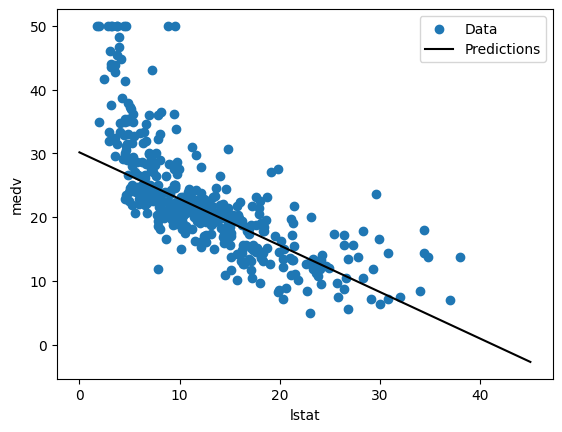

In [369]:
x = tf.linspace(0.0, 45, 46)
y = lin_reg_1_model.predict(x)

def plot_lstat(x, y):
    plt.scatter(train_features["lstat"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("lstat")
    plt.ylabel("medv")
    plt.legend()

plot_lstat(x, y)